# Single Systems: States, Operations & Measurements

In [1]:
from qiskit import __version__

print(__version__)

2.3.0


The `array_to_latex` function in Qiskit, from the `qiskit.visualization` module used along with the `display` function in python allows prettier formatting of vector and matrix outputs.

In [6]:
from qiskit.visualization import array_to_latex

display(array_to_latex(np.matmul(M1, ket1)))
display(array_to_latex(np.matmul(M1, M2)))
display(array_to_latex(np.matmul(M, M)))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

## States, measurements, and operations

### Define and display state vectors

The `Statevector` class from `qiskit.quantum_info` provides functionality for defining and manipulating quantum state vectors.

In [7]:
from qiskit.quantum_info import Statevector
from numpy import sqrt

u = Statevector([1 / sqrt(2), 1 / sqrt(2)])
v = Statevector([(1 + 2.0j) / 3, -2 / 3])
w = Statevector([1 / 3, 2 / 3])

The `Statevector` class includes the `draw` method for displaying state vectors with parameters
- `text` for plain text,
- `latex` for rendered LaTeX
- `latex_source` for LaTeX code (use with the `print` function)

In [10]:
print("Text format")
display(u.draw("text"))

print("Latex format")
display(u.draw("latex"))

print("Latex source format")
print(u.draw("latex_source"))

Text format


[0.70710678+0.j,0.70710678+0.j]

Latex format


<IPython.core.display.Latex object>

Latex source format
\frac{\sqrt{2}}{2} |0\rangle+\frac{\sqrt{2}}{2} |1\rangle


In [9]:
display(v.draw("latex"))
display(w.draw("latex"))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

`is_valid` checks if a given vector is a valid quantum state vector (in other words, that it has Euclidean norm equal to 1)

In [11]:
display(u.is_valid())
display(w.is_valid())

True

False

#### State Example

- Define a $| - \rangle$ state, check if it is valid and display in latex format

In [12]:
km = Statevector([1 / sqrt(2), -1 / sqrt(2)])
display(km.is_valid())
display(km.draw("latex"))

True

<IPython.core.display.Latex object>

### Simulating measurements using `Statevector`

Measurements of quantum states can be simulated in Qiskit, using the `measure` method from the `Statevector` class.

In [11]:
display(v.draw("latex"))

<IPython.core.display.Latex object>

Running the `measure` method simulates a standard basis measurement.
It returns the outcome of that measurement, plus the new quantum state vector of the system after the measurement.

In [22]:
outcome, state = v.measure()
print(f"Measured: {outcome}\nPost-measurement state:")
display(state.draw("latex"))

Measured: 1
Post-measurement state:


<IPython.core.display.Latex object>

Measurement outcomes are probabilistic, so this method can return different results when run multiple times.
For the particular example of the vector `v` defined above, the `measure` method defines the quantum state vector after the measurement takes place to be

$$
(\frac{\sqrt{5}}{5} + \frac{2 \sqrt{5} i}{5}) |0\rangle
$$

(rather than $\vert 0\rangle$) or

$$
- \vert 1\rangle
$$

(rather than $\vert 1\rangle$), depending on the measurement outcome.
In both cases, the alternatives to $\vert 0\rangle$ and $\vert 1\rangle$ are, in fact, equivalent to these state vectors; they are said to to *equivalent up to a global phase* because one is equal to the other multiplied by a complex number on the unit circle.

`Statevector` will throw an error if the `measure` method is applied to an invalid quantum state vector.

`Statevector` also comes with a `sample_counts` method that allows for the simulation of any number of measurements on the system, each time starting with a fresh copy of the state.


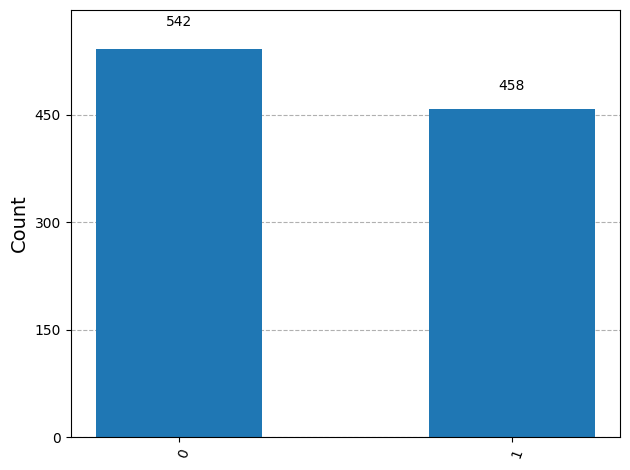

In [23]:
from qiskit.visualization import plot_histogram

statistics = v.sample_counts(1000)
plot_histogram(statistics)

#### Measurement Example

For the $| - \rangle$ state measure it, display the result and post measurement state and plot statistics for `1000` samples of the state

In [28]:

outcome, state = km.measure()
print(f"Measured: {outcome}\nPost-measurement state:")
display(state.draw("latex"))


Measured: 0
Post-measurement state:


<IPython.core.display.Latex object>

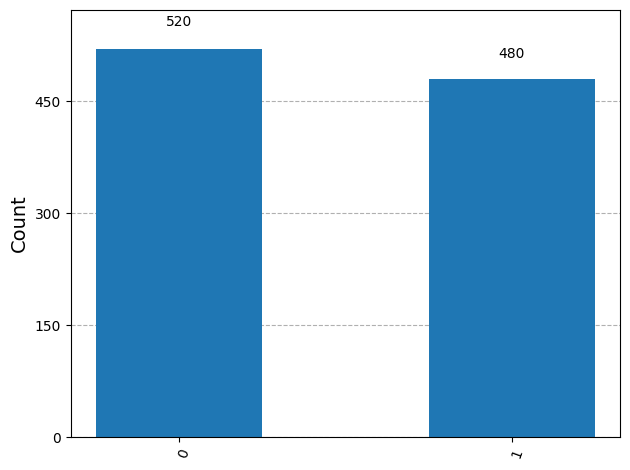

In [29]:
statistics = km.sample_counts(1000)
plot_histogram(statistics)

### Perform operations with `Operator` and `Statevector`

Unitary operations can be defined in Qiskit using the `Operator` class.
This class includes a `draw` method with similar arguments to `Statevector`.

In [33]:
from qiskit.quantum_info import Operator

Y = Operator([[0, -1.0j], [1.0j, 0]])
H = Operator([[1 / sqrt(2), 1 / sqrt(2)], [1 / sqrt(2), -1 / sqrt(2)]])
S = Operator([[1, 0], [0, 1.0j]])
T = Operator([[1, 0], [0, (1 + 1.0j) / sqrt(2)]])


In [34]:
display(Y.draw("latex"))
display(H.draw("latex"))
display(S.draw("latex"))
display(T.draw("latex"))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

We can apply a unitary operation to a state vector using the `evolve` method.



In [35]:
v = Statevector([1, 0])

v = v.evolve(H)
v = v.evolve(T)
v = v.evolve(H)
v = v.evolve(S)
v = v.evolve(Y)

display(v.draw("latex"))

<IPython.core.display.Latex object>

#### Operator example

Apply the Hadamard operation on $| 0 \rangle$ to put it into superposition i.e. `plus` state.

In [36]:
kz = Statevector([1, 0])
display(kz.draw("latex"))

<IPython.core.display.Latex object>

In [37]:
kp = kz.evolve(H)
display(kp.draw("latex"))

<IPython.core.display.Latex object>

### Quantum circuits short note

A quantum circuit composed of a sequence of unitary operations performed on a single qubit.


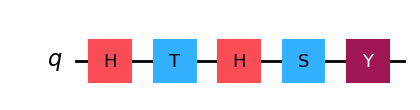

In [38]:
from qiskit import QuantumCircuit

circuit = QuantumCircuit(1)

circuit.h(0)
circuit.t(0)
circuit.h(0)
circuit.s(0)
circuit.y(0)

display(circuit.draw(output="mpl"))

Here we're using the `draw` method from the `QuantumCircuit` class with the `mpl` renderer (short for `Matplotlib`).

The operations are applied sequentially, starting on the left and ending on the right in the diagram.
A handy way to get the unitary matrix corresponding to this circuit is to use the `from_circuit` method from the `Operator` class.



In [32]:
display(Operator.from_circuit(circuit).draw("latex"))

<IPython.core.display.Latex object>

We can also initialize a starting quantum state vector and then evolve that state according to the sequence of operations described by the circuit.



In [41]:
ket0 = Statevector([1, 0])
v = ket0.evolve(circuit)
display(v.draw("latex"))

<IPython.core.display.Latex object>